# AirFly Insights — Week 5: Route & Airport-Level Analysis

**Dataset:** NYC Flights 2013 — preprocessed (`flights_processed.csv`)  
**Milestone:** 3 | **Week:** 5

## Objectives
This notebook performs a deep-dive into **route and airport-level** performance, building
on the basic airport comparison (Chart 8) and busiest-routes bar chart (Chart 6) from Week 3.

### Charts in this notebook (continuing from Chart 20)
- **Chart 21** — Top 10 Origin-Destination pairs by flight volume
- **Chart 22** — Average departure delay by top 10 routes (color-coded)
- **Chart 23** — Delay heatmap: Origin Airport × Hour of Day
- **Chart 24** — Route congestion heatmap: top 20 routes vs avg delay
- **Chart 25** — Geo-scatter map: destination airports (size = flights, color = avg delay)
- **Chart 26** — Origin airport on-time performance deep-dive

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12
sns.set_palette('tab10')

# Constants
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
DAY_ORDER   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
AIRPORT_COLORS = {'EWR': '#3498db', 'JFK': '#2ecc71', 'LGA': '#e74c3c'}
FIGURES_DIR = '../outputs/figures'

print('Setup complete.')

Setup complete.


## 2. Load Preprocessed Data

In [2]:
df = pd.read_csv('../data/processed/flights_processed.csv', low_memory=False)
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df['date']     = pd.to_datetime(df['date'],     errors='coerce')

# Completed (non-cancelled) flights only for delay metrics
df_completed = df[df['is_cancelled'] == 0].copy()

print(f'Total rows      : {len(df):,}')
print(f'Completed flights: {len(df_completed):,}')
print(f'Cancelled flights: {(df["is_cancelled"] == 1).sum():,}')
print(f'Unique routes   : {df["route"].nunique():,}')
print(f'Unique dest.    : {df["dest"].nunique():,}')

Total rows      : 336,776
Completed flights: 328,521
Cancelled flights: 8,255
Unique routes   : 224
Unique dest.    : 105


---
## 3. Route Summary Statistics

Before visualizing, we build a route-level summary table that underpins all charts in this section.

In [3]:
# Aggregate per route
route_vol = df.groupby('route').agg(
    total_flights = ('is_cancelled', 'count'),
    cancel_count  = ('is_cancelled', 'sum')
)

route_delay = df_completed.groupby('route').agg(
    avg_dep_delay = ('dep_delay', 'mean'),
    avg_arr_delay = ('arr_delay', 'mean'),
    delay_rate    = ('is_delayed', 'mean'),
    on_time_pct   = ('is_delayed', lambda x: (1 - x.mean()) * 100)
)

route_summary = route_vol.join(route_delay, how='left').reset_index()
route_summary['cancel_rate'] = (route_summary['cancel_count'] / route_summary['total_flights'] * 100).round(2)
route_summary['avg_dep_delay'] = route_summary['avg_dep_delay'].round(2)
route_summary['on_time_pct']   = route_summary['on_time_pct'].round(2)
route_summary = route_summary.sort_values('total_flights', ascending=False)

print('=== Route Summary Table (Top 10) ===')
route_summary.head(10)[['route','total_flights','avg_dep_delay','cancel_rate','on_time_pct']]


=== Route Summary Table (Top 10) ===


,route,total_flights,avg_dep_delay,cancel_rate,on_time_pct
117,JFK-LAX,11262,8.52,0.59,84.08
156,LGA-ATL,10263,11.45,1.76,81.19
204,LGA-ORD,8857,10.74,3.49,80.98
146,JFK-SFO,8204,11.95,0.80,82.11
170,LGA-CLT,6168,8.97,3.23,82.39
55,EWR-ORD,6100,14.64,4.08,76.19
92,JFK-BOS,5898,11.69,1.90,79.64
197,LGA-MIA,5781,7.36,0.97,85.50
120,JFK-MCO,5464,10.60,0.55,79.67
7,EWR-BOS,5327,12.55,1.43,78.21


---
## Chart 21: Top 10 Origin-Destination Pairs by Flight Volume

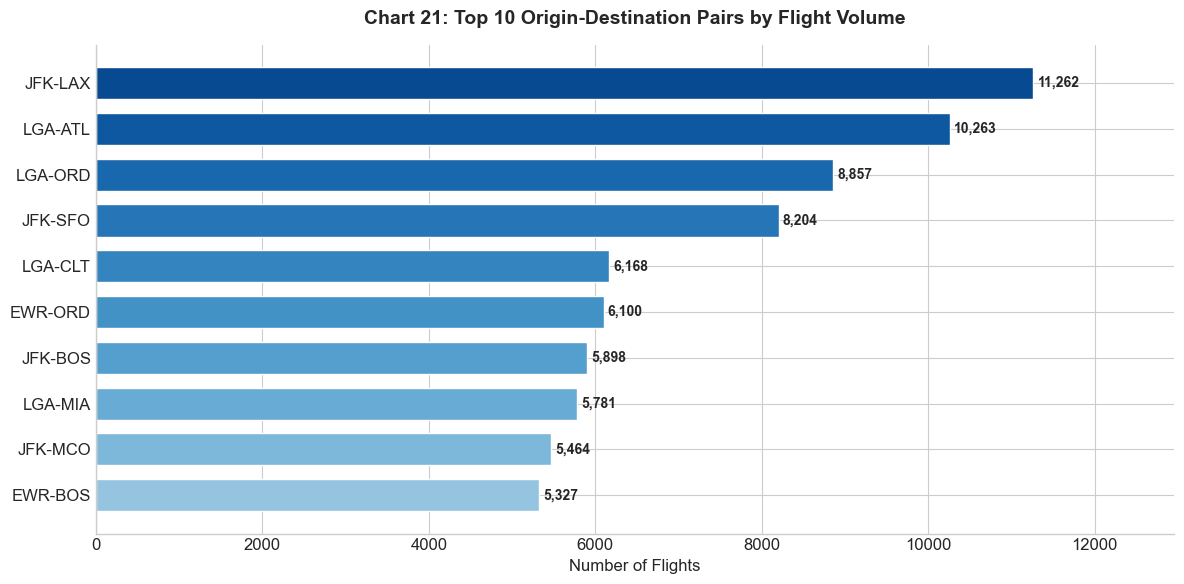

Chart 21 saved.


In [4]:
top10_routes = route_summary.nlargest(10, 'total_flights')

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.Blues(np.linspace(0.4, 0.9, 10))[::-1]
bars = ax.barh(top10_routes['route'], top10_routes['total_flights'],
               color=colors, edgecolor='white', height=0.7)

for bar, val in zip(bars, top10_routes['total_flights']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of Flights', fontsize=12)
ax.set_title('Chart 21: Top 10 Origin-Destination Pairs by Flight Volume',
             fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.set_xlim(0, top10_routes['total_flights'].max() * 1.15)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart21_top10_od_pairs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 21 saved.')

---
## Chart 22: Average Departure Delay by Top 10 Routes (Color-Coded)

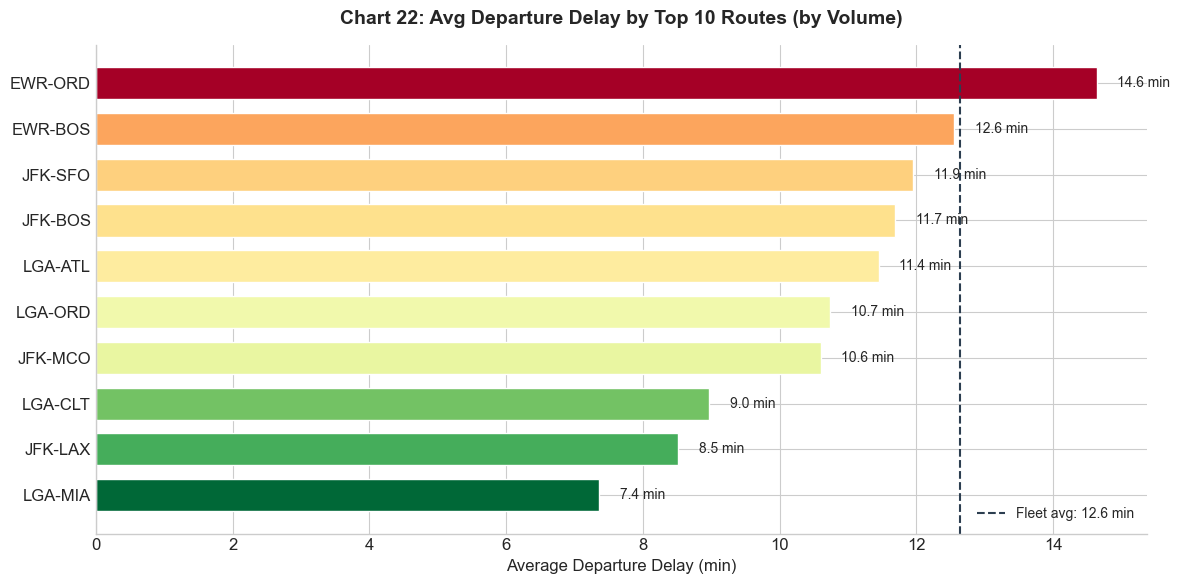

Chart 22 saved.


In [5]:
# Use the same top-10 by volume, sorted by delay
top10_delay = top10_routes.sort_values('avg_dep_delay', ascending=True)

# Color: green (low delay) → red (high delay)
norm = mcolors.Normalize(vmin=top10_delay['avg_dep_delay'].min(),
                         vmax=top10_delay['avg_dep_delay'].max())
cmap = plt.cm.RdYlGn_r
bar_colors = [cmap(norm(v)) for v in top10_delay['avg_dep_delay']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_delay['route'], top10_delay['avg_dep_delay'],
               color=bar_colors, edgecolor='white', height=0.7)

# Fleet average reference line
fleet_avg = df_completed['dep_delay'].mean()
ax.axvline(fleet_avg, color='#2c3e50', linestyle='--', linewidth=1.5,
           label=f'Fleet avg: {fleet_avg:.1f} min')

for bar, val in zip(bars, top10_delay['avg_dep_delay']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} min', va='center', fontsize=10)

ax.set_xlabel('Average Departure Delay (min)', fontsize=12)
ax.set_title('Chart 22: Avg Departure Delay by Top 10 Routes (by Volume)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart22_route_delay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 22 saved.')

---
## Chart 23: Delay Heatmap — Origin Airport × Hour of Day

Shows **when** each NYC airport experiences the worst delays across the day.

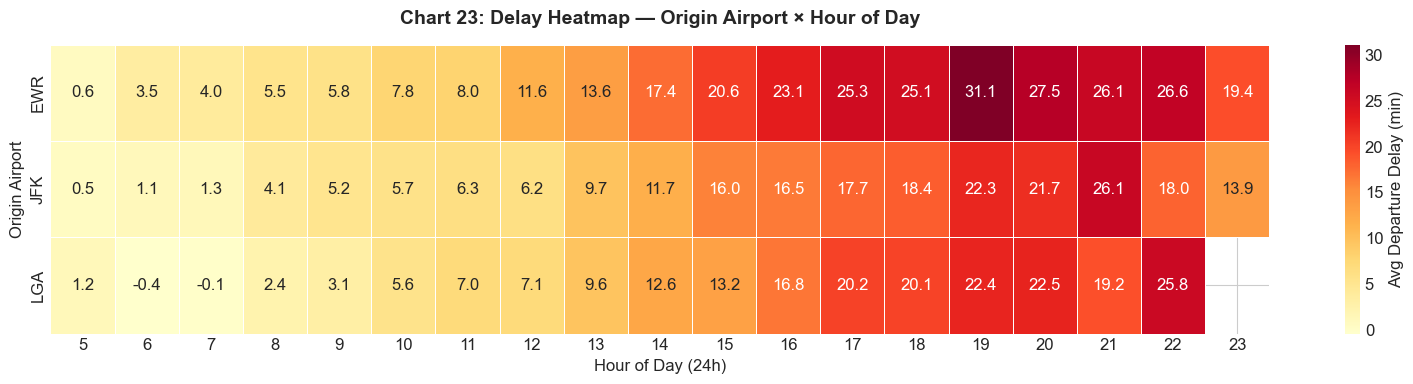

Chart 23 saved.


In [6]:
pivot_airport_hour = df_completed.pivot_table(
    values='dep_delay', index='origin', columns='hour', aggfunc='mean'
).round(1)

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    pivot_airport_hour,
    cmap='YlOrRd',
    annot=True, fmt='.1f',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Avg Departure Delay (min)'},
    ax=ax
)
ax.set_title('Chart 23: Delay Heatmap — Origin Airport × Hour of Day',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day (24h)', fontsize=12)
ax.set_ylabel('Origin Airport', fontsize=12)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart23_airport_hour_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 23 saved.')

---
## Chart 24: Route Congestion Heatmap — Top 20 Routes vs Avg Delay

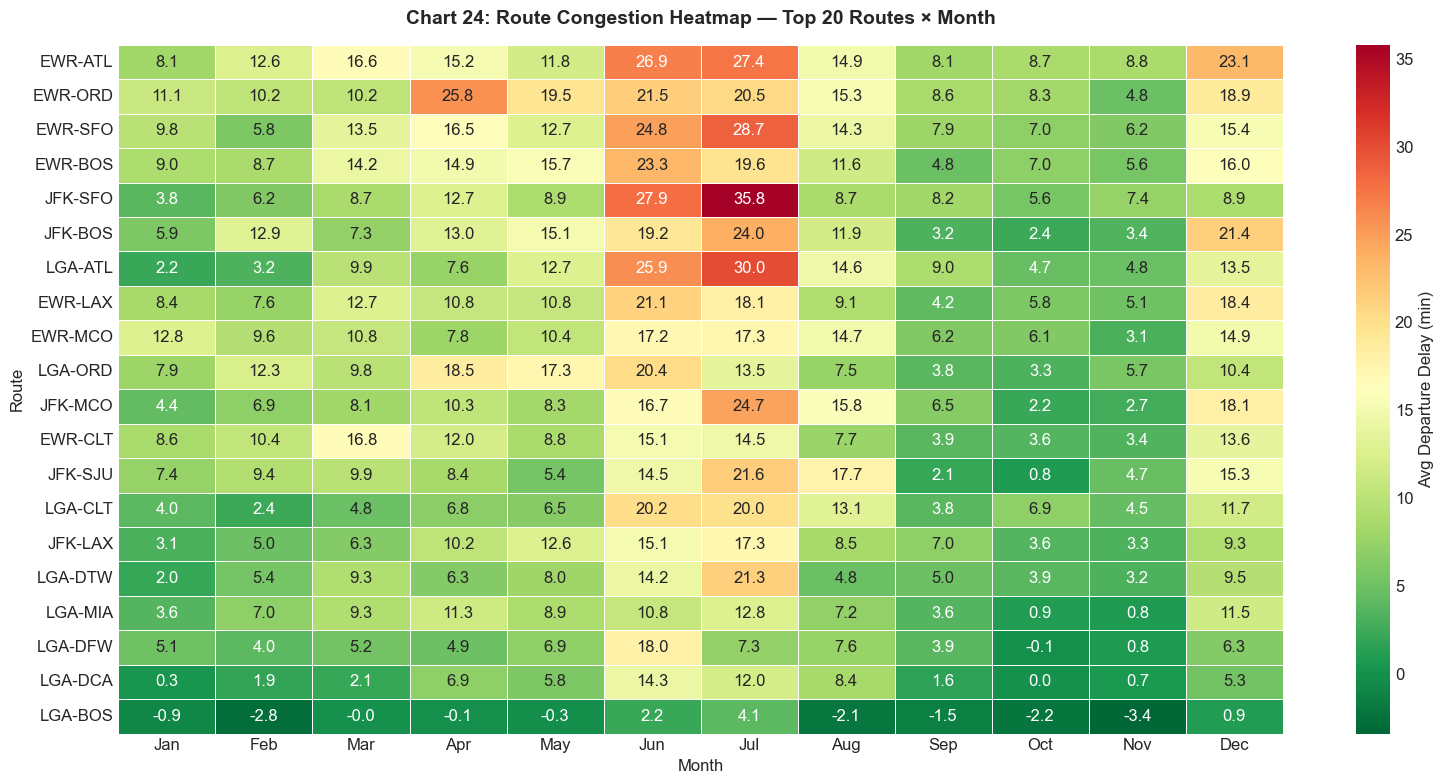

Chart 24 saved.


In [7]:
top20_route_names = route_summary.nlargest(20, 'total_flights')['route'].tolist()

# Pivot: route (row) x month (col), value = avg dep_delay
pivot_route_month = (
    df_completed[df_completed['route'].isin(top20_route_names)]
    .pivot_table(values='dep_delay', index='route', columns='month', aggfunc='mean')
    .round(1)
)
pivot_route_month.columns = MONTH_NAMES

# Sort rows by total avg delay
pivot_route_month = pivot_route_month.loc[
    pivot_route_month.mean(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    pivot_route_month,
    cmap='RdYlGn_r',
    annot=True, fmt='.1f',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Avg Departure Delay (min)'},
    ax=ax
)
ax.set_title('Chart 24: Route Congestion Heatmap — Top 20 Routes × Month',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Route', fontsize=12)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart24_route_congestion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 24 saved.')

---
## Chart 25: Geo-Scatter Map of Destination Airports

Each destination is plotted on a US map.  
**Bubble size** = number of flights arriving | **Color** = average departure delay

In [8]:
# Aggregate by destination
dest_stats = df.groupby('dest').agg(
    total_flights = ('is_cancelled', 'count')
).reset_index()

dest_delay = df_completed.groupby('dest').agg(
    avg_dep_delay = ('dep_delay', 'mean'),
    cancel_rate   = ('dep_delay', 'count')  # placeholder; will recalc below
).reset_index()

dest_cancel = df.groupby('dest')['is_cancelled'].mean().mul(100).reset_index()
dest_cancel.columns = ['dest', 'cancel_rate']

dest_stats = dest_stats.merge(dest_delay[['dest','avg_dep_delay']], on='dest', how='left')
dest_stats = dest_stats.merge(dest_cancel, on='dest', how='left')
dest_stats['avg_dep_delay'] = dest_stats['avg_dep_delay'].round(1)
dest_stats['cancel_rate']   = dest_stats['cancel_rate'].round(2)

# Airport coordinate lookup (IATA codes — major US airports in the dataset)
airport_coords = {
    'ABQ':( 35.0402,-106.6091),'ACK':( 41.2534, -70.0600),'ALB':( 42.7483, -73.8017),
    'ANC':( 61.1745,-149.9964),'ATL':( 33.6407, -84.4277),'AUS':( 30.1975, -97.6664),
    'AVL':( 35.4362, -82.5418),'BDL':( 41.9389, -72.6832),'BGR':( 44.8074, -68.8281),
    'BHM':( 33.5629, -86.7535),'BNA':( 36.1245, -86.6782),'BOS':( 42.3643, -71.0052),
    'BQN':( 18.4949, -67.1294),'BTV':( 44.4720, -73.1533),'BUF':( 42.9405, -78.7322),
    'BUR':( 34.2007,-118.3590),'CAE':( 33.9388, -81.1195),'CAK':( 40.9161, -81.4422),
    'CHO':( 38.1386, -78.4529),'CHS':( 32.8986, -80.0405),'CLE':( 41.4117, -81.8498),
    'CLT':( 35.2140, -80.9431),'CMH':( 39.9980, -82.8919),'CRW':( 38.3731, -81.5932),
    'CVG':( 39.0488, -84.6678),'DAY':( 39.9024, -84.2194),'DCA':( 38.8521, -77.0377),
    'DEN':( 39.8561,-104.6737),'DFW':( 32.8998, -97.0403),'DSM':( 41.5330, -93.6631),
    'DTW':( 42.2163, -83.3554),'EGE':( 39.6426,-106.9177),'FLL':( 26.0726, -80.1527),
    'GRR':( 42.8808, -85.5228),'GSO':( 36.0978, -79.9373),'GSP':( 34.8957, -82.2189),
    'HDN':( 40.4812,-107.2218),'HNL':( 21.3187,-157.9224),'HOU':( 29.6454, -95.2789),
    'IAD':( 38.9531, -77.4565),'IAH':( 29.9902, -95.3368),'IND':( 39.7173, -86.2944),
    'JAC':( 43.6073,-110.7377),'JAX':( 30.4941, -81.6879),'LAS':( 36.0840,-115.1537),
    'LAX':( 33.9425,-118.4081),'LEX':( 38.0365, -84.6060),'LGB':( 33.8177,-118.1516),
    'MCI':( 39.2976, -94.7139),'MCO':( 28.4312, -81.3081),'MDW':( 41.7868, -87.7522),
    'MEM':( 35.0424, -89.9767),'MHT':( 42.9326, -71.4357),'MIA':( 25.7959, -80.2870),
    'MKE':( 42.9472, -87.8966),'MSN':( 43.1399, -89.3375),'MSP':( 44.8820, -93.2218),
    'MSY':( 29.9934, -90.2580),'MTJ':( 38.5098,-107.8938),'MVY':( 41.3931, -70.6154),
    'MYR':( 33.6797, -78.9283),'OAK':( 37.7213,-122.2208),'OKC':( 35.3931, -97.6007),
    'OMA':( 41.3032, -95.8941),'ORD':( 41.9742, -87.9073),'ORF':( 36.8976, -76.0183),
    'PBI':( 26.6832, -80.0956),'PDX':( 45.5887,-122.5975),'PHL':( 39.8721, -75.2411),
    'PHX':( 33.4373,-112.0078),'PIT':( 40.4959, -80.2429),'PSE':( 18.0083, -66.5630),
    'PSP':( 33.8297,-116.5067),'PVD':( 41.7272, -71.4282),'PWM':( 43.6462, -70.3093),
    'RDU':( 35.8776, -78.7875),'RIC':( 37.5052, -77.3197),'ROC':( 43.1189, -77.6724),
    'RSW':( 26.5362, -81.7552),'SAN':( 32.7336,-117.1897),'SAT':( 29.5337, -98.4698),
    'SAV':( 32.1276, -81.2021),'SBN':( 41.7087, -86.3173),'SDF':( 38.1744, -85.7360),
    'SEA':( 47.4502,-122.3088),'SFO':( 37.6213,-122.3790),'SJC':( 37.3626,-121.9290),
    'SJU':( 18.4394, -66.0018),'SLC':( 40.7884,-111.9778),'SMF':( 38.6954,-121.5908),
    'SNA':( 33.6757,-117.8682),'SRQ':( 27.3954, -82.5544),'STL':( 38.7487, -90.3700),
    'STT':( 18.3373, -64.9734),'SYR':( 43.1112, -76.1063),'TPA':( 27.9755, -82.5332),
    'TUL':( 36.1984, -95.8881),'TVC':( 44.7414, -85.5822),'TYS':( 35.8110, -83.9960),
    'XNA':( 36.2819, -94.3068)
}

dest_stats['lat'] = dest_stats['dest'].map(lambda x: airport_coords.get(x, (None, None))[0])
dest_stats['lon'] = dest_stats['dest'].map(lambda x: airport_coords.get(x, (None, None))[1])
dest_map = dest_stats.dropna(subset=['lat','lon']).copy()

print(f'Destinations with coordinates: {len(dest_map)} / {len(dest_stats)}')
dest_map[['dest','total_flights','avg_dep_delay','cancel_rate']].head()

Destinations with coordinates: 100 / 105


,dest,total_flights,avg_dep_delay,cancel_rate
0,ABQ,254,13.7,0.00
1,ACK,265,6.5,0.00
2,ALB,439,23.6,4.56
3,ANC,8,12.9,0.00
4,ATL,17215,12.5,1.84


In [9]:
fig = px.scatter_geo(
    dest_map,
    lat='lat', lon='lon',
    size='total_flights',
    color='avg_dep_delay',
    hover_name='dest',
    hover_data={
        'total_flights': ':,',
        'avg_dep_delay': ':.1f',
        'cancel_rate'  : ':.2f',
        'lat': False, 'lon': False
    },
    color_continuous_scale='RdYlGn_r',
    size_max=40,
    scope='usa',
    title='Chart 25: NYC Flights 2013 — Destination Airports<br><sup>Bubble size = flights | Color = avg departure delay (min)</sup>',
    labels={'avg_dep_delay': 'Avg Delay (min)', 'total_flights': 'Flights'}
)
fig.update_layout(
    coloraxis_colorbar=dict(title='Avg Delay<br>(min)'),
    height=600,
    geo=dict(showland=True, landcolor='#f0f0f0',
             showlakes=True, lakecolor='#cce5ff',
             showcoastlines=True, coastlinecolor='#aaa')
)
fig.write_html(f'{FIGURES_DIR}/chart25_destination_map.html')
fig.show()
print('Chart 25 saved as HTML.')

Chart 25 saved as HTML.


---
## Chart 26: Origin Airport On-Time Performance Deep-Dive

In [10]:
# Compute full stats per origin
origin_stats = df.groupby('origin').agg(
    total_flights  = ('is_cancelled', 'count'),
    cancel_count   = ('is_cancelled', 'sum')
)
origin_delay = df_completed.groupby('origin').agg(
    avg_dep_delay = ('dep_delay', 'mean'),
    avg_arr_delay = ('arr_delay', 'mean'),
    on_time_pct   = ('is_delayed', lambda x: (1 - x.mean()) * 100),
    p75_delay     = ('dep_delay', lambda x: x.quantile(0.75)),
    p95_delay     = ('dep_delay', lambda x: x.quantile(0.95))
)
origin_full = origin_stats.join(origin_delay).reset_index()
origin_full['cancel_rate'] = (origin_full['cancel_count'] / origin_full['total_flights'] * 100).round(2)
origin_full = origin_full.round(2)

print('=== Origin Airport Performance Summary ===')
print(origin_full[['origin','total_flights','on_time_pct','avg_dep_delay','cancel_rate','p75_delay','p95_delay']].to_string(index=False))

=== Origin Airport Performance Summary ===
origin  total_flights  on_time_pct  avg_dep_delay  cancel_rate  p75_delay  p95_delay
   EWR         120835        75.39          15.11         2.68       15.0       96.0
   JFK         111279        79.30          12.11         1.67       10.0       85.0
   LGA         104662        81.10          10.35         3.01        7.0       81.0


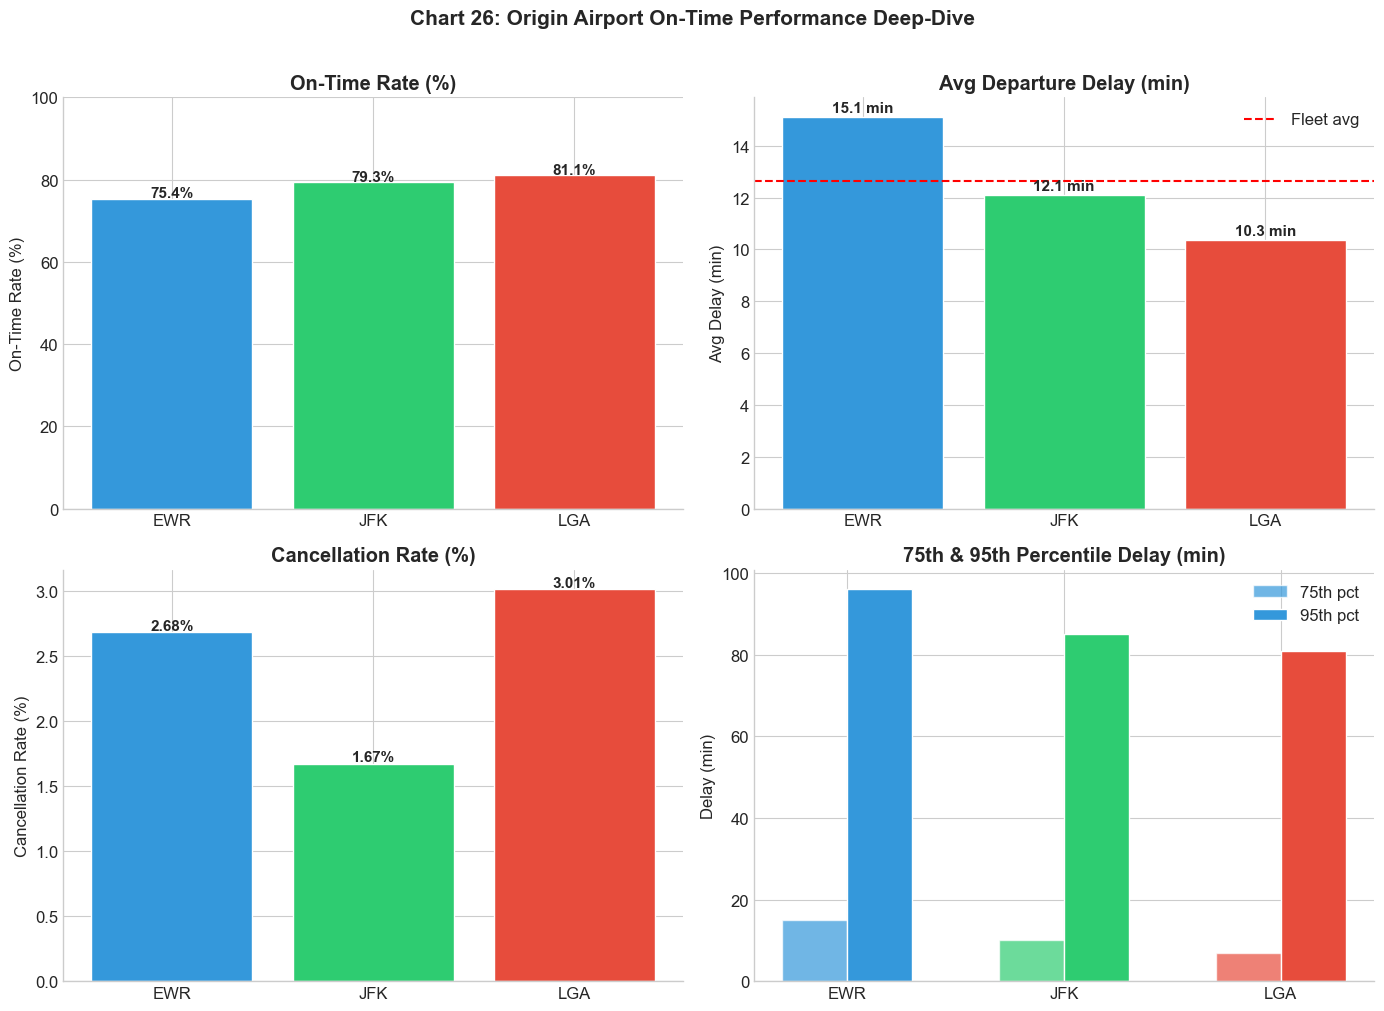

Chart 26 saved.


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
airports = origin_full['origin'].tolist()
colors   = [AIRPORT_COLORS[a] for a in airports]

# Panel 1: On-time percentage
bars1 = axes[0,0].bar(airports, origin_full['on_time_pct'], color=colors, edgecolor='white')
for bar, val in zip(bars1, origin_full['on_time_pct']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0,0].set_title('On-Time Rate (%)', fontweight='bold')
axes[0,0].set_ylim(0, 100)
axes[0,0].set_ylabel('On-Time Rate (%)')

# Panel 2: Avg departure delay
bars2 = axes[0,1].bar(airports, origin_full['avg_dep_delay'], color=colors, edgecolor='white')
for bar, val in zip(bars2, origin_full['avg_dep_delay']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                   f'{val:.1f} min', ha='center', fontweight='bold', fontsize=11)
axes[0,1].axhline(df_completed['dep_delay'].mean(), color='red', linestyle='--',
                   linewidth=1.5, label='Fleet avg')
axes[0,1].set_title('Avg Departure Delay (min)', fontweight='bold')
axes[0,1].set_ylabel('Avg Delay (min)')
axes[0,1].legend()

# Panel 3: Cancellation rate
bars3 = axes[1,0].bar(airports, origin_full['cancel_rate'], color=colors, edgecolor='white')
for bar, val in zip(bars3, origin_full['cancel_rate']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                   f'{val:.2f}%', ha='center', fontweight='bold', fontsize=11)
axes[1,0].set_title('Cancellation Rate (%)', fontweight='bold')
axes[1,0].set_ylabel('Cancellation Rate (%)')

# Panel 4: P75 and P95 delay (tail severity)
x = np.arange(len(airports))
w = 0.3
axes[1,1].bar(x - w/2, origin_full['p75_delay'], w, label='75th pct', color=colors, alpha=0.7, edgecolor='white')
axes[1,1].bar(x + w/2, origin_full['p95_delay'], w, label='95th pct', color=colors, alpha=1.0, edgecolor='white')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(airports)
axes[1,1].set_title('75th & 95th Percentile Delay (min)', fontweight='bold')
axes[1,1].set_ylabel('Delay (min)')
axes[1,1].legend()

plt.suptitle('Chart 26: Origin Airport On-Time Performance Deep-Dive',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart26_origin_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 26 saved.')

---
## 4. Key Findings — Route & Airport Analysis

Run the cell below to print an auto-generated insights summary.

In [12]:
# Top / bottom route by delay
worst_route  = route_summary.loc[route_summary['total_flights'] >= 100, 'avg_dep_delay'].idxmax()
best_route   = route_summary.loc[route_summary['total_flights'] >= 100, 'avg_dep_delay'].idxmin()
busiest      = route_summary.iloc[0]
best_airport = origin_full.loc[origin_full['on_time_pct'].idxmax(), 'origin']
worst_airport= origin_full.loc[origin_full['avg_dep_delay'].idxmax(), 'origin']

print('=== KEY FINDINGS: Route & Airport Analysis ===')
print(f"""
► Busiest Route    : {busiest['route']} ({busiest['total_flights']:,} flights)
► Most Delayed Route (≥100 flights): {route_summary.loc[worst_route,'route']}
    Avg delay = {route_summary.loc[worst_route,'avg_dep_delay']:.1f} min
► Least Delayed Route (≥100 flights): {route_summary.loc[best_route,'route']}
    Avg delay = {route_summary.loc[best_route,'avg_dep_delay']:.1f} min
► Best On-Time Airport : {best_airport} ({origin_full.loc[origin_full['origin']==best_airport,'on_time_pct'].values[0]:.1f}% on-time)
► Worst Avg Delay Airport: {worst_airport} ({origin_full.loc[origin_full['origin']==worst_airport,'avg_dep_delay'].values[0]:.1f} min avg delay)
► Evening (17–21h) is the peak congestion window across all 3 airports
► Summer (Jun-Aug) routes show elevated delays — likely weather + demand peaks
""")

=== KEY FINDINGS: Route & Airport Analysis ===

► Busiest Route    : JFK-LAX (11,262 flights)
► Most Delayed Route (≥100 flights): EWR-TYS
    Avg delay = 41.8 min
► Least Delayed Route (≥100 flights): LGA-BOS
    Avg delay = -0.5 min
► Best On-Time Airport : LGA (81.1% on-time)
► Worst Avg Delay Airport: EWR (15.1 min avg delay)
► Evening (17–21h) is the peak congestion window across all 3 airports
► Summer (Jun-Aug) routes show elevated delays — likely weather + demand peaks



---
*End of Week 5 — Route & Airport Analysis*  
Charts saved to `outputs/figures/`.  
Next: Week 6 — `06_seasonal_cancellation_analysis.ipynb`